In [5]:
import torch
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
import models
import torch.nn.utils.prune as prune
import sympy
from sympy import symbols, Matrix
from sympy import symbols, sin, cos, exp, Abs, sqrt, log, Piecewise

In [6]:
# Define the equivalent SymPy functions
def Sin(x):
    return sin(x)

def Cos(x):
    return cos(x)

def Exp(x):
    return exp(x)

def ExpN(x):
    return exp(-x)

def ExpAbs(x):
    return exp(-0.01 * Abs(x))

def ExpAbsP(x):
    return exp(0.01 * Abs(x))

def Sqrt(x):
    #Approximation of square root to avoid instability
    relu = Piecewise((x, x > 0), (0, True))  # ReLU equivalent
    return sqrt(0.01 + relu)

def Log(x):
    #Approximation of log to avoid instability
    relu = Piecewise((x, x > 0), (0, True))  # ReLU equivalent
    return log(0.1 + relu)

def Id(x):
    return x

# Create the list of symbolic functions
functions = [Sin, Cos, ExpAbs, ExpAbsP, Sqrt, Log, Id]

In [7]:
device = 'cpu'

In [192]:
model = models.MixFunn(normalization_function = False,
                       normalization_neuron = False,
                       p_drop = False,
                       second_order_input = False,
                       second_order_function = True
                       ).to(device)

# load checkpoint if it exists
model.load_state_dict(torch.load('best_model_1.pt', weights_only=True)['model'])

# for key in list(state_dict.keys()):
#     if "weight_orig" in key:
#         base_key = key.replace(".weight_orig", ".weight")
#         mask_key = key.replace(".weight_orig", ".weight_mask")
#         state_dict[base_key] = state_dict[key] * state_dict[mask_key]
#         del state_dict[key]
#         del state_dict[mask_key]

# model.load_state_dict(state_dict, strict=False)

#(optional) prune parameters
# prune.l1_unstructured(model.layers[0].project1.linear, 'weight', amount=0.5)
# prune.l1_unstructured(model.layers[0].project1.linear, 'bias', amount=0.5)

# prune.l1_unstructured(model.layers[0].project2_1.linear, 'weight', amount=0.5)
# prune.l1_unstructured(model.layers[0].project2_1.linear, 'bias', amount=0.5)
# prune.l1_unstructured(model.layers[0].project2_2.linear, 'weight', amount=0.5)
# prune.l1_unstructured(model.layers[0].project2_2.linear, 'bias', amount=0.5)

p = model.layers[0].p.data
print(p.shape)
L = torch.sum(abs(p))
P = abs(p)/L
values, indices = torch.sort(p)
mask1 = torch.zeros(indices.shape[1], device=device)
for k in range(indices.shape[1]):
    if k < int(0.99*indices.shape[1]):
        #mask1[indices[0][k]] = 1.0
        p[0,indices[0][k]] = 0.0

torch.Size([1, 35])


In [193]:
# Define the symbols for the input
t = symbols('t')

# Define the input vector
inputs = Matrix([t])

inputs

Matrix([[t]])

In [194]:
second_order_function = model.layers[0].second_order_function
if second_order_function:
    w1 = model.layers[0].project1.linear.weight.data.cpu().numpy()
    b1 = model.layers[0].project1.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))

    w2_1 = model.layers[0].project2_1.linear.weight.data.cpu().numpy()
    b2_1 = model.layers[0].project2_1.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))

    w2_2 = model.layers[0].project2_2.linear.weight.data.cpu().numpy()
    b2_2 = model.layers[0].project2_2.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))
else:
    w = model.layers[0].project1.linear.weight.data.cpu().numpy()
    b = model.layers[0].project1.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))

In [195]:
if second_order_function:
    result1 = (w1 @ inputs) + b1
    result1 = result1.reshape(model.layers[0].n_out, len(functions))
    result1.T

    result2_1 = (w2_1 @ inputs) + b2_1
    result2_1 = result2_1.reshape(model.layers[0].n_out, len(functions))
    result2_1.T

    result2_2 = (w2_2 @ inputs) + b2_2
    result2_2 = result2_2.reshape(model.layers[0].n_out, len(functions))
    result2_2.T
else:
    result = (w @ inputs) + b
    result = result.reshape(model.layers[0].n_out, len(functions))
    result.T

In [196]:
# Apply each function to the result vector
#result2 = Matrix([func(res) for func, res in zip(functions, result)])
#result2 = Matrix([functions[i](result[:, i]) for i in range(len(functions))])
if second_order_function:
    result_2_1 = Matrix([[functions[i](elem) for elem in result1[:, i]] for i in range(len(functions))])
    result_2_2_1 = Matrix([[functions[i](elem) for elem in result2_1[:, i]] for i in range(len(functions))])
    result_2_2_2 = Matrix([[functions[i](elem) for elem in result2_2[:, i]] for i in range(len(functions))])
else:
    result_2 = Matrix([[functions[i](elem) for elem in result[:, i]] for i in range(len(functions))])

In [197]:
result_2_1

Matrix([
[                                                            -sin(1.03483*t - 15.2416)],
[                                                            cos(0.932165*t + 1.06221)],
[                                                  exp(-0.01*Abs(7.42533*t + 22.7727))],
[                                                exp(0.01*Abs(0.041869*t - 0.0992722))],
[ sqrt(Piecewise((-2.25736*t - 0.933069, 2.25736*t + 0.933069 < 0), (0, True)) + 0.01)],
[log(Piecewise((0.00938613*t + 4.69626, 0.00938613*t + 4.69626 > 0), (0, True)) + 0.1)],
[                                                               0.335572 - 0.0248034*t]])

In [198]:
product_matrix = []
for i in range(result_2_2_1.rows):
    for j in range(result_2_2_2.rows):
            if j >= i:
                product_matrix.append(result_2_2_1[i] * result_2_2_2[j])

result_2_2 = Matrix(product_matrix)
result_2_2

Matrix([
[                                                                                                                        -sin(0.168046*t - 3.1123)*sin(1.00619*t + 1.49731)],
[                                                                                                                        sin(1.00619*t + 1.49731)*cos(0.0632285*t - 1.5752)],
[                                                                                                              exp(-0.01*Abs(8.55972*t + 13.6005))*sin(1.00619*t + 1.49731)],
[                                                                                                             exp(0.01*Abs(0.159642*t - 0.325856))*sin(1.00619*t + 1.49731)],
[                                                           sqrt(Piecewise((-0.154472*t - 0.626766, 0.154472*t + 0.626766 < 0), (0, True)) + 0.01)*sin(1.00619*t + 1.49731)],
[                                                              log(Piecewise((0.007651*t + 0.853527, 0.007651*t + 0.85352

In [199]:
result2 = Matrix.vstack(result_2_1, result_2_2)
result2

Matrix([
[                                                                                                                                                 -sin(1.03483*t - 15.2416)],
[                                                                                                                                                 cos(0.932165*t + 1.06221)],
[                                                                                                                                       exp(-0.01*Abs(7.42533*t + 22.7727))],
[                                                                                                                                     exp(0.01*Abs(0.041869*t - 0.0992722))],
[                                                                                      sqrt(Piecewise((-2.25736*t - 0.933069, 2.25736*t + 0.933069 < 0), (0, True)) + 0.01)],
[                                                                                     log(Piecewise((0.00938613*t + 4.696

In [200]:
normalization_function = model.layers[0].normalization_function
normalization_neuron = model.layers[0].normalization_neuron
if normalization_function is True and normalization_neuron is False:
    p = model.layers[0].p1
    temperature = model.layers[0].temperature
    p = torch.exp(-p/temperature)
    Z = torch.sum(p, axis=1).reshape((p.shape[0], 1))
    p =  p/(1e-8 + Z)
if normalization_function is False and normalization_neuron is False:
    p = model.layers[0].p

p = p.detach().cpu().numpy().T  
result3 = Matrix(p * (np.array(result2)))
result3

Matrix([
[                                                                            0],
[                                                                            0],
[                                                                            0],
[                                                                            0],
[                                                                            0],
[                                                                            0],
[                                                                            0],
[                                                                            0],
[                                                                            0],
[1.08589959144592*exp(-0.01*Abs(8.55972*t + 13.6005))*sin(1.00619*t + 1.49731)],
[                                                                            0],
[                                                                            0],
[                  

In [201]:
result4 = Matrix([sum(result3.col(i)) for i in range(result3.cols)])

In [202]:
result4

Matrix([[1.08589959144592*exp(-0.01*Abs(8.55972*t + 13.6005))*sin(1.00619*t + 1.49731)]])

In [203]:
if normalization_function is True or normalization_neuron is True:
    amplitude = model.layers[0].amplitude.detach().cpu().numpy()
    result5 = Matrix([amplitude[i] * result4[i] for i in range(len(amplitude))])
else:
    result5 = 1*result4

result5

Matrix([[1.08589959144592*exp(-0.01*Abs(8.55972*t + 13.6005))*sin(1.00619*t + 1.49731)]])

In [204]:
function = result5[0]

In [205]:
function

1.08589959144592*exp(-0.01*Abs(8.55972*t + 13.6005))*sin(1.00619*t + 1.49731)

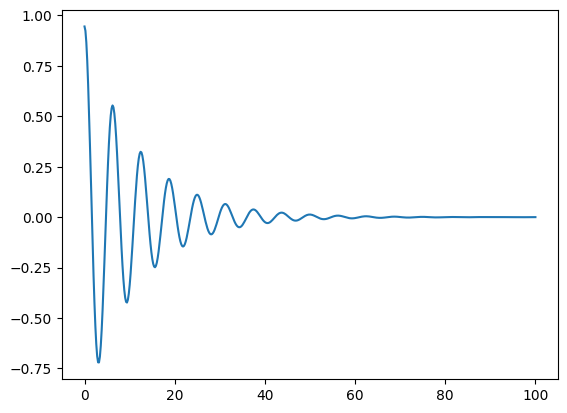

In [206]:
import matplotlib.pyplot as plt
from sympy.utilities.lambdify import lambdify


func = lambdify(t, function, 'numpy')

# Define x as a NumPy array
x_values = np.linspace(0, 100, 500)

# Evaluate the function for all values of x
result2_numpy = func(x_values)

plt.plot(x_values, result2_numpy)